In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import skfuzzy as fuzz
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## **Building a Mamdani Inference from Scratch**
We will implement the complete Mamdani inference pipeline step by step using the **project staffing** example from the lectures.

**Problem:** A project's **risk** depends on its **funding** level and **staffing** level.

**Linguistic variables:**
**Funding (0–100%):** Inadequate, Marginal, Adequate
**Staffing (0–20 people):** Small, Large
**Risk (0–100%):** Low, Normal, High

**Rules:**
1. IF funding IS adequate OR staffing IS small THEN risk IS low
2. IF funding IS marginal AND staffing IS large THEN risk IS normal
3. IF funding IS inadequate THEN risk IS high

**Crisp inputs (from lectures):** funding = 35%, staffing = 60%.

The slides use staffing as a percentage (0–100%), but let's adopt staffing as headcount (1–20) here.

### Step 1 Defining Membership Functions

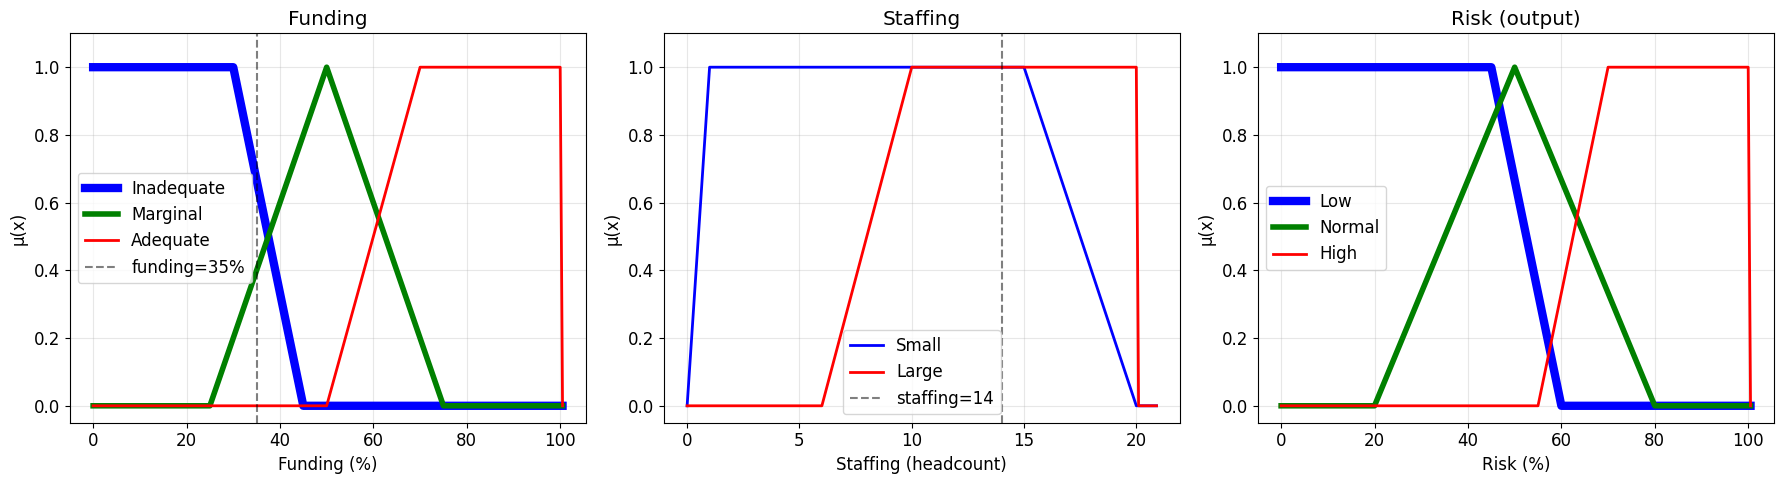

In [4]:
# Universes of discourse
x_fund = np.arange(0, 101, 0.5)
x_staff = np.arange(0, 21, 0.1)
x_risk = np.arange(0, 101, 0.5)

# --- Funding MFs ---
# Inadequate: (0,1)→(30,1)→(45,0) — trapezoidal left-shoulder
fund_inadequate = fuzz.trapmf(x_fund, [0, 0, 30, 45])
# Marginal: triangle (25, 50, 75)
# TODO: create the "marginal" fuzzy set here
# Tip: use skfuzzy's "trimf" function
fund_marginal = fuzz.trimf(x_fund, [25, 50, 75])

# Adequate: (50,0)→(70,1)→(100,1) — trapezoidal right-shoulder
# TODO: create the "adequate" fuzzy set here
fund_adequate = fuzz.trapmf(x_fund, [50, 70, 100, 100])

# --- Staffing MFs ---
# Small: (1,1)→(15,0) left-shoulder trapezoid
# TODO: create the "small" fuzzy set here
staff_small = fuzz.trapmf(x_staff, [0, 1, 15, 20])

# Large: (6,0)→(20,1) right-shoulder trapezoid
# TODO: create the "large" fuzzy set here
staff_large = fuzz.trapmf(x_staff, [6, 10, 20, 20])

# --- Risk MFs ---
# Low: (0,1)→(45,0) left-shoulder trapezoid
# TODO: create the "low" fuzzy set here
risk_low = fuzz.trapmf(x_risk, [0, 0, 45, 60])

# Normal: triangle (20, 50, 80)
# TODO: create the "normal" fuzzy set here
risk_normal = fuzz.trimf(x_risk, [20, 50, 80])

# High: (55,0)→(100,1) right-shoulder trapezoid
# TODO: create the "high" fuzzy set here
risk_high = fuzz.trapmf(x_risk, [55, 70, 100, 100])

# --- Plot ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
ax1.plot(x_fund, fund_inadequate, 'b-', lw=6, label='Inadequate')
ax1.plot(x_fund, fund_marginal, 'g-', lw=4, label='Marginal')
ax1.plot(x_fund, fund_adequate, 'r-', lw=2, label='Adequate')
ax1.axvline(x=35, color='k', ls='--', alpha=0.5, label='funding=35%')
ax1.set_title('Funding')
ax1.set_xlabel('Funding (%)')
ax1.set_ylabel('μ(x)')
ax1.legend()

ax2.plot(x_staff, staff_small, 'b-', lw=2, label='Small')
ax2.plot(x_staff, staff_large, 'r-', lw=2, label='Large')
ax2.axvline(x=14, color='k', ls='--', alpha=0.5, label='staffing=14')
ax2.set_title('Staffing')
ax2.set_xlabel('Staffing (headcount)')
ax2.set_ylabel('μ(x)')
ax2.legend()

ax3.plot(x_risk, risk_low, 'b-', lw=6, label='Low')
ax3.plot(x_risk, risk_normal, 'g-', lw=4, label='Normal')
ax3.plot(x_risk, risk_high, 'r-', lw=2, label='High')
ax3.set_title('Risk (output)')
ax3.set_xlabel('Risk (%)')
ax3.set_ylabel('μ(x)')
ax3.legend()

for ax in [ax1, ax2, ax3]:
    ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()

### Step 2 Fuzzification